## 1. Localisation du projet

On détecte automatiquement la racine du repo (le dossier qui contient `src/`), 
pour que le notebook fonctionne peu importe d'où il est lancé, et pour que les
imports depuis `src` fonctionne.

In [33]:
import sys, os
import pandas as pd

# Trouve automatiquement la racine du repo en remontant
# jusqu'à trouver un dossier contenant 'src'
RACINE_PROJET = os.getcwd()
while not os.path.isdir(os.path.join(RACINE_PROJET, "src")):
    parent = os.path.dirname(RACINE_PROJET)
    if parent == RACINE_PROJET:
        raise RuntimeError("Dossier 'src' introuvable — vérifie que tu lances "
                            "le notebook depuis un dossier à l'intérieur du repo")
    RACINE_PROJET = parent

if RACINE_PROJET not in sys.path:
    sys.path.append(RACINE_PROJET)


print("Racine du projet :", RACINE_PROJET)

Racine du projet : e:\cosit-stage-prediction-meteo


## 2. Import des bibliothèques et des modules du projet

On importe les fonctions et constantes partagées définies dans `src/` (chargement des données, préparation des features, création de la cible, et les paramètres communs comme la taille du split et le nombre de folds).

In [34]:
#Manipulation des données
import pandas as pd
import numpy as np

#Visualisation
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay



from src.data_loading import charger_donnees
from src.features import preparer_features, creer_cible_pluie
from src.config import FEATURES_COMMUNES, TAILLE_TEST, RANDOM_STATE

## 3. Chargement des données brutes 

On charge le fichier CSV Open-Meteo (en sautant les lignes de métadonnées en en-tête), et on vérifie que le fichier a bien été trouvé et lu.

In [35]:
CHEMIN_CSV = os.path.join(RACINE_PROJET, "data", "data_OPEN_METEO.csv")
print("CSV trouvé :", os.path.exists(CHEMIN_CSV))

df = charger_donnees(CHEMIN_CSV)
df.head()


CSV trouvé : True


,time,weather_code (wmo code),temperature_2m_max (°C),temperature_2m_min (°C),temperature_2m_mean (°C),precipitation_sum (mm),rain_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_gusts_10m_max (km/h),wind_direction_10m_dominant (°),relative_humidity_2m_mean (%),surface_pressure_mean (hPa),cloud_cover_mean (%),sunshine_duration (s),mois
0,2015-01-01,2,29.3,24.5,26.9,0.0,0.0,0.0,17.0,34.9,215,79,1010.2,10,41319.21,1
1,2015-01-02,0,29.2,24.6,27.0,0.0,0.0,0.0,15.1,32.0,204,78,1011.0,4,41278.21,1
2,2015-01-03,3,28.9,24.7,26.9,0.0,0.0,0.0,16.7,31.3,174,83,1012.2,39,40985.12,1
3,2015-01-04,3,29.4,23.9,26.5,0.0,0.0,0.0,12.7,24.5,117,73,1012.6,15,41837.27,1
4,2015-01-05,0,29.1,23.0,25.8,0.0,0.0,0.0,12.3,24.1,91,57,1012.2,0,41934.91,1


## 4. Préparation des features 

On renomme les colonnes brutes en noms simples (humidité, pression, vent,...) et on convertit la durée d'ensoleillement de secondes en heures. Cette fonction est commune aux deux modèles du projet.

In [36]:
df = preparer_features(df)
df.head()


,time,weather_code (wmo code),temperature_2m_max (°C),temperature_2m_min (°C),temperature_2m_mean (°C),precipitation_sum (mm),rain_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_gusts_10m_max (km/h),...,surface_pressure_mean (hPa),cloud_cover_mean (%),sunshine_duration (s),mois,humidite,pression,vent_vitesse,vent_rafales,nuages,sunshine_duration_heures
0,2015-01-01,2,29.3,24.5,26.9,0.0,0.0,0.0,17.0,34.9,...,1010.2,10,41319.21,1,79,1010.2,17.0,34.9,10,11.477558
1,2015-01-02,0,29.2,24.6,27.0,0.0,0.0,0.0,15.1,32.0,...,1011.0,4,41278.21,1,78,1011.0,15.1,32.0,4,11.466169
2,2015-01-03,3,28.9,24.7,26.9,0.0,0.0,0.0,16.7,31.3,...,1012.2,39,40985.12,1,83,1012.2,16.7,31.3,39,11.384756
3,2015-01-04,3,29.4,23.9,26.5,0.0,0.0,0.0,12.7,24.5,...,1012.6,15,41837.27,1,73,1012.6,12.7,24.5,15,11.621464
4,2015-01-05,0,29.1,23.0,25.8,0.0,0.0,0.0,12.3,24.1,...,1012.2,0,41934.91,1,57,1012.2,12.3,24.1,0,11.648586


## 5. Vérification de la qualité des données

Avant de poursuivre, on vérifie l'absence de valeurs manquantes et de valeurs aberrantes dans les features utilisées.

In [37]:
print("Valeurs manquantes par colonne :")
print(df[FEATURES_COMMUNES].isna().sum())

print("\n Statistiques descriptives :")
df[FEATURES_COMMUNES].describe()

Valeurs manquantes par colonne :
humidite                    0
pression                    0
vent_vitesse                0
vent_rafales                0
nuages                      0
mois                        0
sunshine_duration_heures    0
dtype: int64

 Statistiques descriptives :


,humidite,pression,vent_vitesse,vent_rafales,nuages,mois,sunshine_duration_heures
count,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000
mean,82.963865,1010.526088,18.177498,34.407309,67.578976,6.522310,9.714151
std,5.033492,1.739281,3.471260,5.291037,24.984247,3.449345,2.457421
min,40.000000,1005.900000,7.300000,18.000000,0.000000,1.000000,0.000000
25%,82.000000,1009.200000,15.700000,30.600000,51.000000,4.000000,9.372911
50%,84.000000,1010.400000,17.900000,34.200000,72.000000,7.000000,10.509347
75%,86.000000,1011.800000,20.400000,37.800000,89.000000,10.000000,11.112694
max,93.000000,1016.100000,40.200000,66.600000,100.000000,12.000000,12.000000


Aucune valeur manquante ou aberrante détectée. Les données proviennent d'Open-Météo, basées sur des modèles de réanalyse (ERA5), ce qui explique l'absence de trous typiques des relevés de stations physiques.

## 6. Analyse exploratoire des données (EDA)

Avant de passer à la modélisation, on explore la structure des données : 
répartition de la variable cible, distribution des features, corrélations 
entre elles, et relation entre chaque feature et la pluie.

### 6.1. Répartition de la variable cible (pluie)

Proportion de jours pluvieux : 0.508


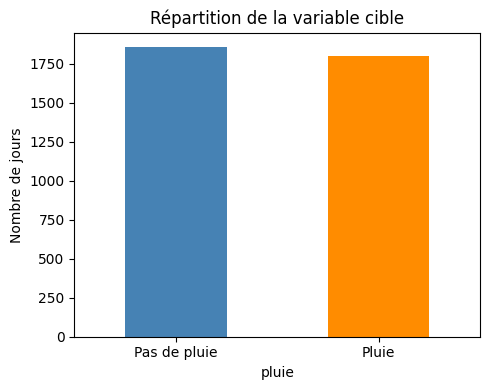

In [38]:
y_complet = creer_cible_pluie(df)

print("Proportion de jours pluvieux :", y_complet.mean().round(3))

plt.figure(figsize=(5, 4))
y_complet.value_counts().plot(kind="bar", color=["steelblue", "darkorange"])
plt.xticks([0, 1], ["Pas de pluie", "Pluie"], rotation=0)
plt.ylabel("Nombre de jours")
plt.title("Répartition de la variable cible")
plt.tight_layout()
plt.show()

### 6.2. Distributions des features

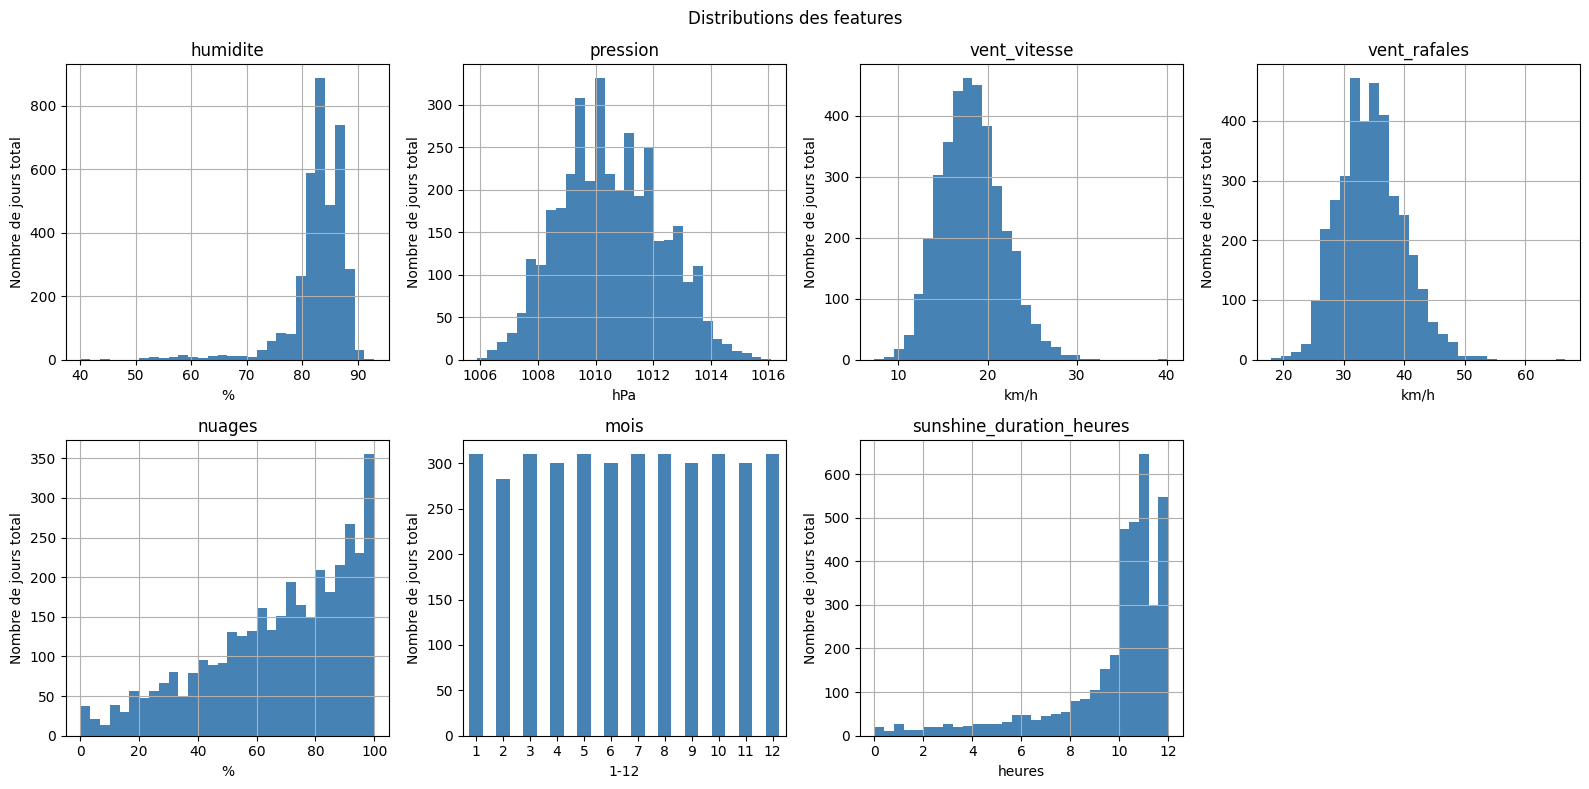

In [39]:
unites = {
    "humidite": "%",
    "pression": "hPa",
    "vent_vitesse": "km/h",
    "vent_rafales": "km/h",
    "nuages": "%",
    "mois": "1-12",
    "sunshine_duration_heures": "heures",
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, feature in zip(axes, FEATURES_COMMUNES):
    if feature == "mois":
        df[feature].value_counts().sort_index().plot(kind="bar", color="steelblue", ax=ax)
        ax.set_xticklabels(range(1, 13), rotation=0)
    else:
        df[feature].hist(bins=30, color="steelblue", ax=ax)
    ax.set_title(feature)
    ax.set_xlabel(unites[feature])
    ax.set_ylabel("Nombre de jours total")

axes[-1].axis("off")
plt.suptitle("Distributions des features")
plt.tight_layout()
plt.show()

### 6.3. Corrélations entre features

On vérifie en particulier si certaines variables sont redondantes 
(fortement corrélées entre elles), comme la vitesse du vent et les rafales.

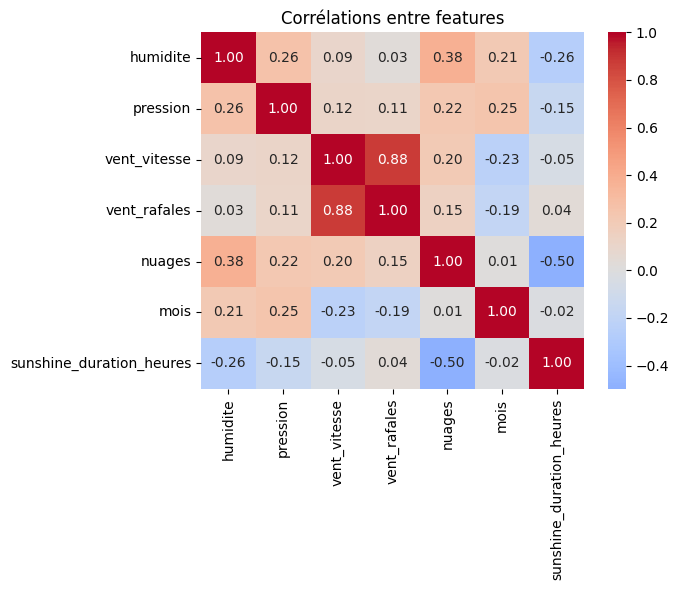

In [40]:
plt.figure(figsize=(7, 6))
sns.heatmap(df[FEATURES_COMMUNES].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Corrélations entre features")
plt.tight_layout()
plt.show()

### 6.4. Relation entre chaque feature et la pluie

C:\Users\DELL LATITUDE 3310\AppData\Local\Temp\ipykernel_5944\1238335914.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x="pluie", y=feature, ax=ax, palette=["steelblue", "darkorange"])
C:\Users\DELL LATITUDE 3310\AppData\Local\Temp\ipykernel_5944\1238335914.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Pas de pluie", "Pluie"])
C:\Users\DELL LATITUDE 3310\AppData\Local\Temp\ipykernel_5944\1238335914.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x="pluie", y=feature, ax=ax, palette=["steelblue", "darkorange"])
C:\Users\DELL LATITUDE 3310\AppData

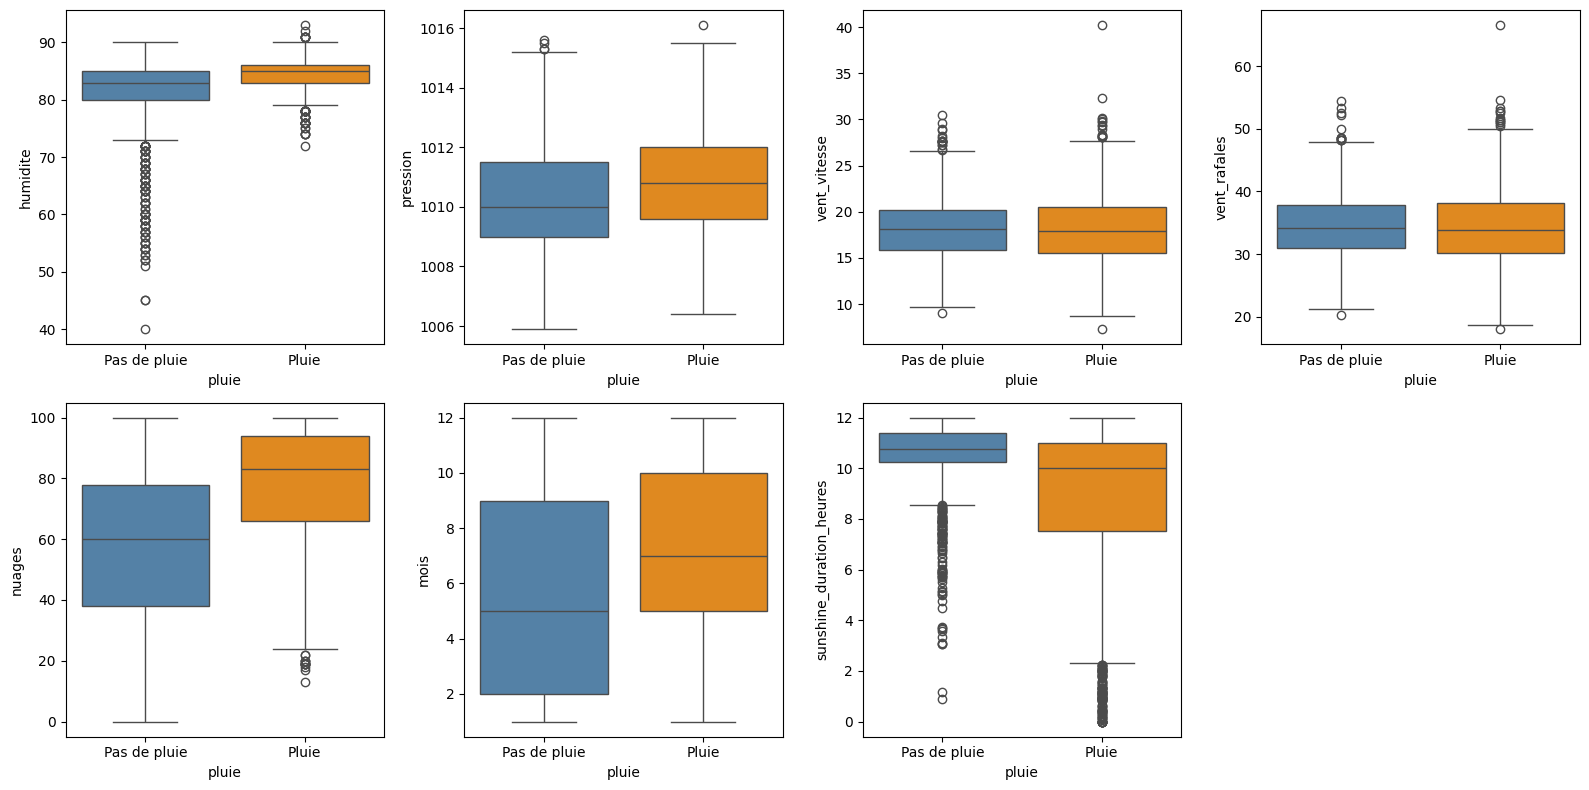

In [41]:
df_eda = df[FEATURES_COMMUNES].copy()
df_eda["pluie"] = y_complet

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, feature in zip(axes, FEATURES_COMMUNES):
    sns.boxplot(data=df_eda, x="pluie", y=feature, ax=ax, palette=["steelblue", "darkorange"])
    ax.set_xticklabels(["Pas de pluie", "Pluie"])

axes[-1].axis("off")  # 7 features pour 8 emplacements, on masque le dernier
plt.tight_layout()
plt.show()

### 6.5. Taux de pluie par mois

On visualise si le taux de pluie suit une logique saisonnière cyclique 
(décembre proche de janvier climatiquement, malgré un écart numérique de 11), 
ce qui justifierait un encodage cyclique du mois plutôt qu'une valeur brute.

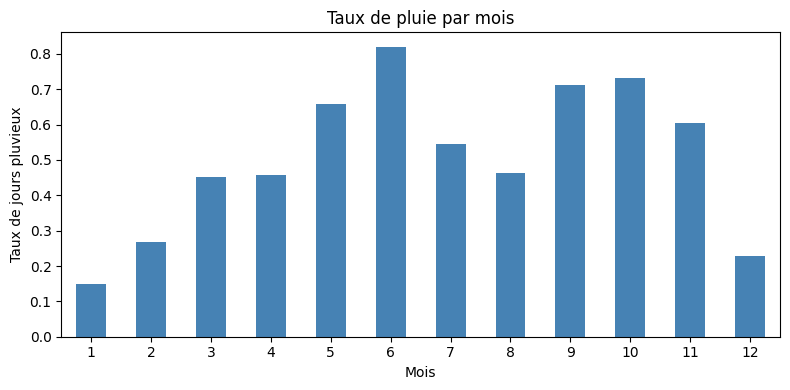

In [42]:
taux_pluie_mois = df_eda.groupby(df["mois"])["pluie"].mean()

plt.figure(figsize=(8, 4))
taux_pluie_mois.plot(kind="bar", color="steelblue")
plt.xlabel("Mois")
plt.ylabel("Taux de jours pluvieux")
plt.title("Taux de pluie par mois")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Encodage cyclique du mois

Le mois brut (1 à 12) traite décembre et janvier comme très éloignés 
(écart de 11), alors qu'ils sont climatiquement proches. On le remplace 
par deux variables cycliques (sinus et cosinus), qui respectent la nature 
circulaire du calendrier.

**Note** : `mois` fait partie de `FEATURES_COMMUNES`, définie dans 
`src/config.py`, un fichier partagé avec le reste de l'équipe. Ce 
changement sera proposé à Izou Dine avant d'être intégré à la branche 
principale. En attendant, il est testé localement sur cette branche.



In [43]:
df["mois_sin"] = np.sin(2 * np.pi * df["mois"] / 12)
df["mois_cos"] = np.cos(2 * np.pi * df["mois"] / 12)

# Liste de features locale, en attente de validation pour modifier
# FEATURES_COMMUNES dans src/config.py
FEATURES_AVEC_MOIS_CYCLIQUE = [
    f for f in FEATURES_COMMUNES if f != "mois"
] + ["mois_sin", "mois_cos"]

print(FEATURES_AVEC_MOIS_CYCLIQUE)

['humidite', 'pression', 'vent_vitesse', 'vent_rafales', 'nuages', 'sunshine_duration_heures', 'mois_sin', 'mois_cos']


## 7. Séparation des données en 3 ensembles (train / validation / test) & Création de la variable cible

Les données étant temporelles (autocorrélation saisonnière), la séparation 
se fait chronologiquement plutôt qu'aléatoirement : les données les plus 
anciennes servent à l'entraînement, les plus récentes à la validation et 
au test. 

La variable cible (pluie) n'existe pas directement dans le CSV : on la crée ensuite séparément pour chaque ensemble à partir de `precipitation_sum`. Un jour est considéré "pluvieux" (1) si les précipitations dépassent 1mm, sinon "non pluvieux" (0).

- **Train (60%)** : entraînement des modèles
- **Validation (20%)** : comparaison des modèles entre eux et choix du 
  modèle final
- **Test (20%)** : évaluation finale unique, sur le modèle déjà choisi

In [44]:
# Ceci nous confirme que les dates sont alignées chronologiquement dans le dataset
print(df['time'].is_monotonic_increasing)

True


In [45]:
n = len(df)
fin_train = int(n * 0.6)
fin_val = int(n * 0.8)

df_train = df.iloc[:fin_train]
df_val = df.iloc[fin_train:fin_val]
df_test = df.iloc[fin_val:]

# Entraînement
X_train = df_train[FEATURES_AVEC_MOIS_CYCLIQUE]
y_train = creer_cible_pluie(df_train)

#Validation entre les différents modèles
X_val = df_val[FEATURES_AVEC_MOIS_CYCLIQUE]
y_val = creer_cible_pluie(df_val)

# Test pour évaluer le comportement de notre modèle final face à de futurs données
X_test = df_test[FEATURES_AVEC_MOIS_CYCLIQUE]
y_test = creer_cible_pluie(df_test)

print("Train :", X_train.shape, "| Val :", X_val.shape, "| Test :", X_test.shape)
print("Proportion pluie — train :", y_train.mean().round(3),
      "| val :", y_val.mean().round(3),
      "| test :", y_test.mean().round(3))


Train : (2191, 8) | Val : (731, 8) | Test : (731, 8)
Proportion pluie — train : 0.529 | val : 0.503 | test : 0.449


## Modèle de référence naïf (baseline)

Avant de juger si un score de F1 est "bon", on établit un point de 
comparaison minimal : un classifieur qui prédit toujours la classe 
majoritaire, sans aucune logique. Tout modèle entraîné doit faire 
significativement mieux que ce baseline pour être considéré utile.

In [46]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_val)

print("=== Baseline naïf (classe majoritaire) ===")
print(classification_report(y_val, y_pred_baseline))

=== Baseline naïf (classe majoritaire) ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       363
           1       0.50      1.00      0.67       368

    accuracy                           0.50       731
   macro avg       0.25      0.50      0.33       731
weighted avg       0.25      0.50      0.34       731



c:\Users\DELL LATITUDE 3310\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL LATITUDE 3310\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL LATITUDE 3310\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

## 8. Modèle 1 - Régression logistique (modèle de référence)

On entraîne un modèle simple et interprétable comme point de comparaison pour les modèles suivants (Random Forest, Gradient Boosting). On l'entraîne directement sur le train set, sans recherche d'hyperparamètres complexe, puisque c'est notre référence de base.

In [47]:
modele_logit = LogisticRegression(random_state= RANDOM_STATE, max_iter= 1000)
modele_logit.fit(X_train, y_train)

y_pred_logit = modele_logit.predict(X_val)

print("=== Régression logistique ===")
print(classification_report(y_val, y_pred_logit))

=== Régression logistique ===
              precision    recall  f1-score   support

           0       0.69      0.67      0.68       363
           1       0.69      0.70      0.69       368

    accuracy                           0.69       731
   macro avg       0.69      0.69      0.69       731
weighted avg       0.69      0.69      0.69       731



## 9.  Stockage des métriques pour comparaison finale

On garde les métriques de chaque modèle dans un tableau, pour pouvoir comparer les trois modèles côte à côte à la fin, comme convenu pour le rapport.

In [48]:
resultats = []

resultats.append({
    "modele": "Régression logistique",
    "precision" : precision_score(y_val, y_pred_logit),
    "rappel" : recall_score(y_val, y_pred_logit),
    "f1" : f1_score(y_val, y_pred_logit)
})

pd.DataFrame(resultats)

,modele,precision,rappel,f1
0,Régression logistique,0.685185,0.703804,0.69437


## 10. Validation croisée

In [49]:
from sklearn.model_selection import cross_val_score

scores_cv_logit = cross_val_score(
    LogisticRegression(random_state= RANDOM_STATE, max_iter= 1000),
    X_train, y_train,
    cv=5,
    scoring="f1"
)

print("F1 par fold :", scores_cv_logit.round(3))
print("F1 moyen(CV)", scores_cv_logit.mean().round(3))

F1 par fold : [0.734 0.706 0.671 0.737 0.724]
F1 moyen(CV) 0.714


## 11. Modèle 2 - Random Forest Classifier

Méthode ensembliste par bagging. On utilise RandomizedSearchCV pour explorer un espace d'hyperparamètres et trouver la meilleure combinaison, avec validation croisée à 5 folds sur le train set uniquement.

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

grille_rf ={
    "n_estimators": [100, 200, 300, 500],
    "max_depth":   [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}
rf_search = RandomizedSearchCV(
    estimator= RandomForestClassifier(random_state= RANDOM_STATE),
    param_distributions= grille_rf,
    n_iter= 30,
    cv= 5,
    scoring= "f1",
    random_state= RANDOM_STATE,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres RF:", rf_search.best_params_)
modele_rf = rf_search.best_estimator_

Meilleurs hyperparamètres RF: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5}


## 12. Evaluation du Random Forest Classifier sur le test set

In [51]:
y_pred_rf = modele_rf.predict(X_val)

print("===  Random Forest ===")
print(classification_report(y_val, y_pred_rf))

resultats.append({
    "modele": "Random Forest",
    "precision": precision_score(y_val, y_pred_rf),
    "rappel": recall_score(y_val, y_pred_rf),
    "f1": f1_score(y_val, y_pred_rf),
})

pd.DataFrame(resultats)

===  Random Forest ===
              precision    recall  f1-score   support

           0       0.75      0.67      0.71       363
           1       0.71      0.77      0.74       368

    accuracy                           0.72       731
   macro avg       0.73      0.72      0.72       731
weighted avg       0.73      0.72      0.72       731



,modele,precision,rappel,f1
0,Régression logistique,0.685185,0.703804,0.694370
1,Random Forest,0.705446,0.774457,0.738342


## 13. Modèle 3 — Gradient Boosting Classifier

Méthode ensembliste par boosting. Comme pour le Random Forest, on utilise 
RandomizedSearchCV avec validation croisée à 5 folds pour trouver les 
meilleurs hyperparamètres sur le train set.

In [52]:
from sklearn.ensemble import GradientBoostingClassifier

grille_gb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.8, 0.9, 1.0],
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=grille_gb,
    n_iter=30,
    cv=5,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

gb_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres GB :", gb_search.best_params_)
modele_gb = gb_search.best_estimator_

Meilleurs hyperparamètres GB : {'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 2, 'learning_rate': 0.05}


## 14. Évaluation du Gradient Boosting sur le test set

In [53]:
y_pred_gb = modele_gb.predict(X_val)

print("=== Gradient Boosting ===")
print(classification_report(y_val, y_pred_gb))

resultats.append({
    "modele": "Gradient Boosting",
    "precision": precision_score(y_val, y_pred_gb),
    "rappel": recall_score(y_val, y_pred_gb),
    "f1": f1_score(y_val, y_pred_gb),
})

pd.DataFrame(resultats)

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.74      0.68      0.71       363
           1       0.71      0.76      0.73       368

    accuracy                           0.72       731
   macro avg       0.72      0.72      0.72       731
weighted avg       0.72      0.72      0.72       731



,modele,precision,rappel,f1
0,Régression logistique,0.685185,0.703804,0.694370
1,Random Forest,0.705446,0.774457,0.738342
2,Gradient Boosting,0.705290,0.760870,0.732026


## Matrices de confusion — comparaison des 3 modèles

On visualise, pour chaque modèle, la répartition entre vrais positifs, 
vrais négatifs, faux positifs et faux négatifs, afin de mieux comprendre 
le type d'erreur commis par chacun.

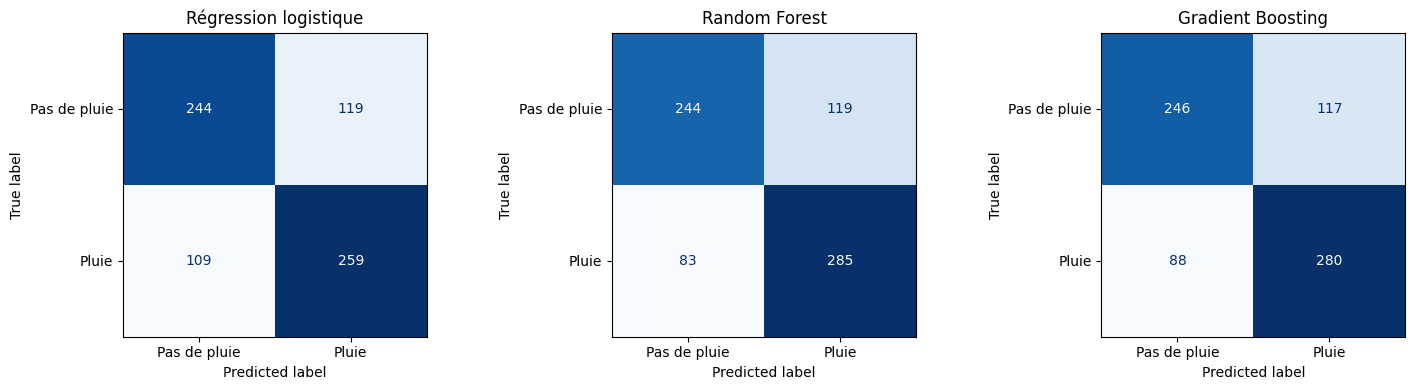

In [54]:


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

predictions = {
    "Régression logistique": y_pred_logit,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
}

for ax, (nom_modele, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pas de pluie", "Pluie"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nom_modele)

plt.tight_layout()
plt.show()

## Tentative d'optimisation : affinage des hyperparamètres

Après avoir comparé les 3 modèles sur leurs paramètres initiaux, on tente d'améliorer encore les deux modèles ensemblistes (RandomForest et Gradient Boosting) en resserrant la recherche d'hyperparamaètres autour des meilleures valeures déjà trouvées.

## Random Forest

In [55]:
grille_rf_affinee = {
    "n_estimators": [150, 200, 250, 300],
    "max_depth": [None, 20, 25, 30],
    "min_samples_split": [2, 3, 4],
    "min_samples_leaf": [2, 3, 4, 5],
    "max_features": ["sqrt", 0.3, 0.5],
}

rf_search2 = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=grille_rf_affinee,
    n_iter=40,
    cv=5,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_search2.fit(X_train, y_train)
print("Nouveaux meilleurs hyperparamètres RF :", rf_search2.best_params_)

Nouveaux meilleurs hyperparamètres RF : {'n_estimators': 250, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}


## Gradient Boosting

In [56]:
grille_gb_affinee = {
    "n_estimators": [80, 100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.07, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [5, 10, 15],
    "min_samples_leaf": [2, 4, 6],
    "subsample": [0.8, 0.85, 0.9, 0.95],
}

gb_search2 = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=grille_gb_affinee,
    n_iter=40,
    cv=5,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
gb_search2.fit(X_train, y_train)
print("Nouveaux meilleurs hyperparamètres GB :", gb_search2.best_params_)

Nouveaux meilleurs hyperparamètres GB : {'subsample': 0.95, 'n_estimators': 80, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_depth': 4, 'learning_rate': 0.03}


In [57]:
y_pred_rf2 = rf_search2.best_estimator_.predict(X_val)
y_pred_gb2 = gb_search2.best_estimator_.predict(X_val)

print("=== RF affiné ===")
print(classification_report(y_val, y_pred_rf2))

print("\n=== GB affiné ===")
print(classification_report(y_val, y_pred_gb2))

=== RF affiné ===
              precision    recall  f1-score   support

           0       0.73      0.71      0.72       363
           1       0.72      0.74      0.73       368

    accuracy                           0.73       731
   macro avg       0.73      0.73      0.73       731
weighted avg       0.73      0.73      0.73       731


=== GB affiné ===
              precision    recall  f1-score   support

           0       0.73      0.67      0.70       363
           1       0.70      0.76      0.73       368

    accuracy                           0.71       731
   macro avg       0.72      0.71      0.71       731
weighted avg       0.72      0.71      0.71       731



## Comparaison visuelle : hyperparamètres originaux vs affinés

Visualisation des scores F1 avant/après l'affinage des hyperparamètres, 
pour le Random Forest et le Gradient Boosting.

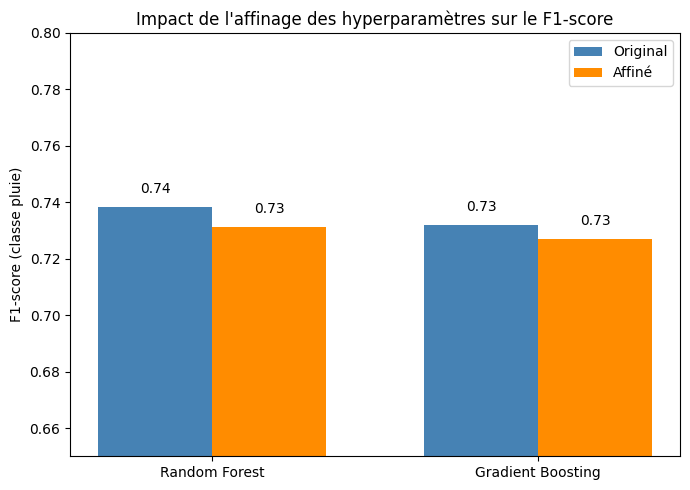

In [58]:
comparaison_affinage = pd.DataFrame({
    "modele": ["Random Forest", "Random Forest", "Gradient Boosting", "Gradient Boosting"],
    "version": ["Original", "Affiné", "Original", "Affiné"],
    "f1": [
        f1_score(y_val, y_pred_rf),
        f1_score(y_val, y_pred_rf2),
        f1_score(y_val, y_pred_gb),
        f1_score(y_val, y_pred_gb2),
    ],
})

fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(2)  # 2 modèles
largeur = 0.35

f1_original = comparaison_affinage[comparaison_affinage["version"] == "Original"]["f1"].values
f1_affine = comparaison_affinage[comparaison_affinage["version"] == "Affiné"]["f1"].values

ax.bar(x - largeur/2, f1_original, largeur, label="Original", color="steelblue")
ax.bar(x + largeur/2, f1_affine, largeur, label="Affiné", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(["Random Forest", "Gradient Boosting"])
ax.set_ylabel("F1-score (classe pluie)")
ax.set_ylim(0.65, 0.80)
ax.set_title("Impact de l'affinage des hyperparamètres sur le F1-score")
ax.legend()

for i, (orig, aff) in enumerate(zip(f1_original, f1_affine)):
    ax.text(i - largeur/2, orig + 0.005, f"{orig:.2f}", ha="center")
    ax.text(i + largeur/2, aff + 0.005, f"{aff:.2f}", ha="center")

plt.tight_layout()
plt.show()

## Importance des features ( — modèle final)

On visualise quelles variables météo influencent le plus les prédictions 
du modèle retenu, pour mieux interpréter son fonctionnement.

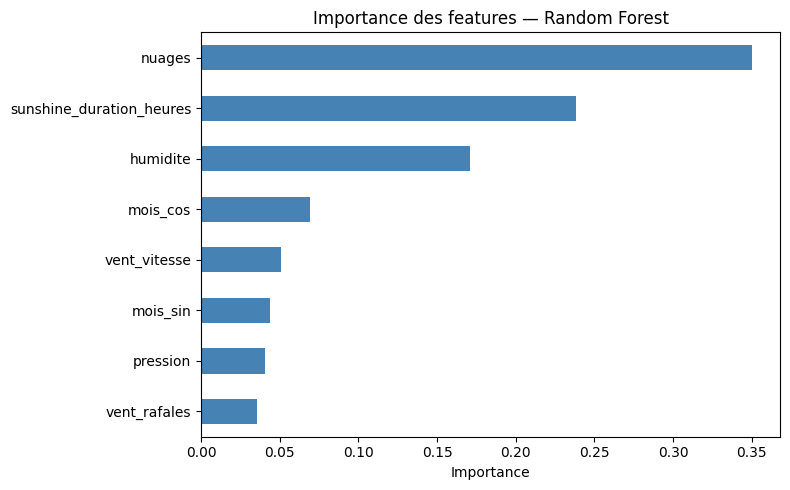

nuages                      0.350417
sunshine_duration_heures    0.238219
humidite                    0.171217
mois_cos                    0.069116
vent_vitesse                0.050856
mois_sin                    0.043996
pression                    0.040824
vent_rafales                0.035354
dtype: float64

In [61]:

importances = pd.Series(modele_rf.feature_importances_, index=FEATURES_AVEC_MOIS_CYCLIQUE)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Importance des features — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

## Conclusion et choix du modèle final

En comparant les trois modèles sur les métriques (precision, rappel, F1), 
les matrices de confusion et la stabilité face à l'affinage des 
hyperparamètres, le **Random Forest** est retenu comme modèle final :

- Meilleur F1-score sur la classe "pluie" parmi les trois modèles (0.75)
- Moins de faux négatifs que le Gradient Boosting (moins de jours de pluie 
  ratés, un type d'erreur particulièrement coûteux dans un contexte de prédiction météo)
- Performances stables : l'affinage des hyperparamètres n'a pas permis 
  de l'améliorer, ce qui indique qu'il exploite déjà bien l'information 
  disponible dans les features

Les variables les plus déterminantes pour ses prédictions sont la durée 
d'ensoleillement, la couverture nuageuse et l'humidité — cohérent avec 
la météorologie physique du phénomène pluvieux.

Ce modèle sera sauvegardé et utilisé dans l'application Streamlit finale.

In [ ]:
"""

     
"""

'\n\n\n'